<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [76]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing_cl=housing.copy()

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [77]:
print(housing_cl.shape)
print(housing_cl.info())
print(housing_cl.isnull().sum())

(985, 12)
<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB
None
street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64


In [78]:
#sale_date from string to date

In [79]:
housing_cl['sale_date']=housing_cl['sale_date'].str.replace('EDT ', '', regex=False)
housing_cl['sale_date'].head()
housing_cl['sale_date'] = pd.to_datetime(housing_cl['sale_date'], format='%a %b %d %H:%M:%S %Y')
print(housing_cl['sale_date'].dtype)

datetime64[us]


In [80]:
#zip from int to string

In [81]:
housing_cl['zip']=housing_cl['zip'].astype(str)

In [82]:
housing_cl.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,985.000000,985.000000,985.000000,985,985.000000,985.000000,985.000000
mean,2.911675,1.776650,1312.918782,2008-05-18 05:12:51.167512,233715.951269,38.445121,-121.193371
min,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,2.000000,1.000000,950.000000,2008-05-16 00:00:00,145000.000000,38.482704,-121.446119
50%,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,213750.000000,38.625932,-121.375799
75%,4.000000,2.000000,1718.000000,2008-05-20 00:00:00,300000.000000,38.695589,-121.294893
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,1.307932,0.895371,856.123224,NaN,139088.818896,5.103637,5.100670


In [83]:
housing_cl['price'].sort_values()

703   -210944
865      1551
866      2000
555      4897
599      4897
        ...  
553    760000
157    830000
334    839000
863    879000
864    884790
Name: price, Length: 985, dtype: int64

In [84]:
housing_cl['sq__ft'].sort_values()

703    -984
973       0
970       0
798       0
794       0
       ... 
317    3992
535    4246
534    4303
864    4400
866    5822
Name: sq__ft, Length: 985, dtype: int64

In [85]:
housing_cl[housing_cl['beds']<=0]

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
73,17 SERASPI CT,SACRAMENTO,95834,CA,0,0,0,Residential,2008-05-21,206000,38.631481,-121.501880
89,2866 KARITSA AVE,SACRAMENTO,95833,CA,0,0,0,Residential,2008-05-21,244500,38.626671,-121.525970
100,12209 CONSERVANCY WAY,RANCHO CORDOVA,95742,CA,0,0,0,Residential,2008-05-21,263500,38.553867,-121.219141
121,5337 DUSTY ROSE WAY,RANCHO CORDOVA,95742,CA,0,0,0,Residential,2008-05-21,320000,38.528575,-121.228600
126,2115 SMOKESTACK WAY,SACRAMENTO,95833,CA,0,0,0,Residential,2008-05-21,339500,38.602416,-121.542965
...,...,...,...,...,...,...,...,...,...,...,...,...
901,1530 TOPANGA LN Unit 204,LINCOLN,95648,CA,0,0,0,Condo,2008-05-15,138000,38.884150,-121.270277
917,501 POPLAR AVE,WEST SACRAMENTO,95691,CA,0,0,0,Residential,2008-05-15,165000,38.584526,-121.534609
934,1550 TOPANGA LN Unit 207,LINCOLN,95648,CA,0,0,0,Condo,2008-05-15,188000,38.884170,-121.270222
947,1525 PENNSYLVANIA AVE,WEST SACRAMENTO,95691,CA,0,0,0,Residential,2008-05-15,200100,38.569943,-121.527539


In [86]:
housing_cl.loc[703]

street          1900 DANBROOK DR
city                  SACRAMENTO
zip                        95835
state                         AC
beds                           1
baths                          1
sq__ft                      -984
type                       Condo
sale_date    2008-05-16 00:00:00
price                    -210944
latitude             -121.503471
longitude              38.668433
Name: 703, dtype: object

In [87]:
housing_cl = housing_cl.drop(index=703)

In [88]:
housing_cl.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,984.000000,984.000000,984.000000,984,984.000000,984.000000,984.000000
mean,2.913618,1.777439,1315.253049,2008-05-18 05:16:05.853658,234167.841463,38.607670,-121.355832
min,0.000000,0.000000,0.000000,2008-05-15 00:00:00,1551.000000,38.241514,-121.551704
25%,2.000000,1.000000,951.500000,2008-05-16 00:00:00,145000.000000,38.482714,-121.446121
50%,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,214375.000000,38.626257,-121.376010
75%,4.000000,2.000000,1718.500000,2008-05-20 00:00:00,300000.000000,38.695611,-121.295557
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,-120.597599
std,1.307175,0.895484,853.416702,NaN,138434.220875,0.145494,0.138268


In [89]:
housing_cl = housing_cl[(housing_cl['price'] > 0) & (housing_cl['sq__ft'] > 0)]

In [90]:
housing_cl.shape

(813, 12)

In [91]:
housing_cl.describe()

,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,813.000000,813.000000,813.000000,813,813.000000,813.000000,813.000000
mean,3.247232,1.961870,1591.892989,2008-05-18 05:01:06.420664,229471.130381,38.576931,-121.378533
min,1.000000,1.000000,484.000000,2008-05-15 00:00:00,2000.000000,38.241514,-121.550527
25%,3.000000,2.000000,1144.000000,2008-05-16 00:00:00,148750.000000,38.473814,-121.451444
50%,3.000000,2.000000,1419.000000,2008-05-19 00:00:00,207973.000000,38.591618,-121.404999
75%,4.000000,2.000000,1851.000000,2008-05-20 00:00:00,285000.000000,38.674864,-121.325730
max,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,0.849012,0.669367,663.908347,NaN,119897.576889,0.126352,0.119730


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [92]:
housing_cl.to_csv('./data/cleaned.csv' , index=False )

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [93]:
#beds-baths-sq__ft

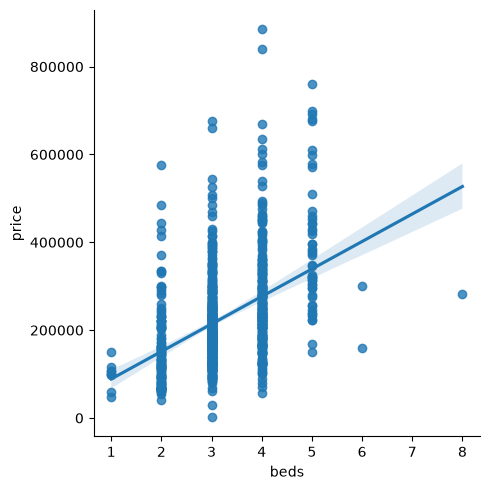

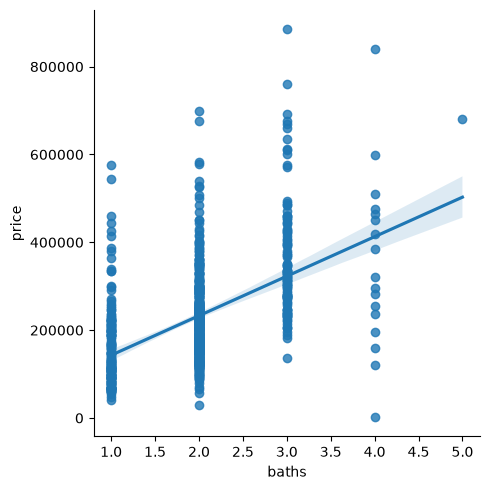

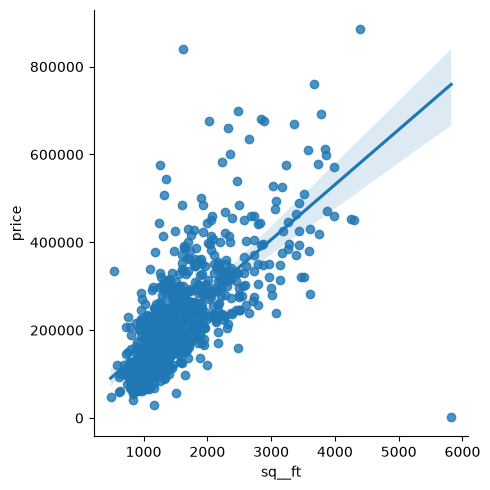

In [94]:
sns.lmplot(data = housing_cl , x='beds' , y='price')
plt.show()

sns.lmplot(data = housing_cl , x='baths' , y='price')
plt.show()

sns.lmplot(data = housing_cl , x='sq__ft' , y='price')
plt.show()

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

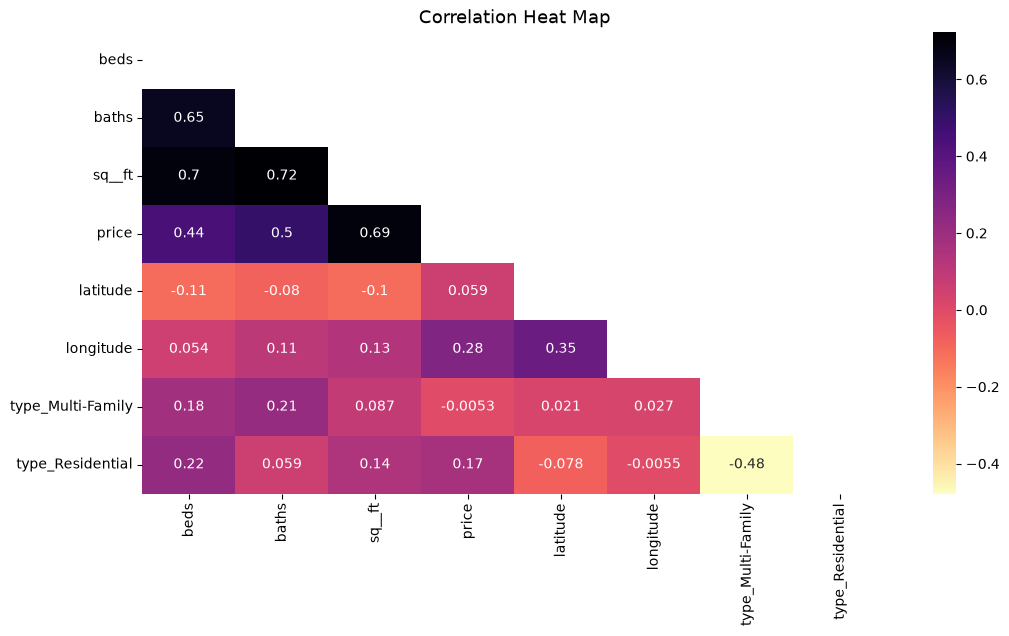

In [108]:
plt.figure(figsize=(12, 6))

sns.heatmap(housing_cl.corr(numeric_only=True), 
            annot=True, 
            mask=np.triu(housing_cl.corr(numeric_only=True)), 
            annot_kws={"size": 10}, cmap ='magma_r' )

plt.title('Correlation Heat Map', size=13)
plt.yticks(rotation = 0)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


In [95]:
#sq__ft it has the best linear relationship

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [96]:
def slop_inter(x , y) :
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    s_x=np.std(x)
    s_y=np.std(y)
    r_x_y=np.corrcoef(x , y)[0,1]

    slope = r_x_y*(s_y/s_x)
    intercept= y_bar -(slope*x_bar)
    return slope, intercept
    

### 6. Interpret the intercept and the slope.

In [97]:
slope, intercept = slop_inter(housing_cl['sq__ft'] ,housing_cl['price'] )
print(f'The slope is {slope}')
print(f'The intercept is{intercept}')


The slope is 125.31418257510143
The intercept is29984.36172651974


### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [98]:
#suppose x =3000 ,then y_hat =
y_hat = intercept + slope*3000
y_hat

np.float64(405926.90945182403)

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

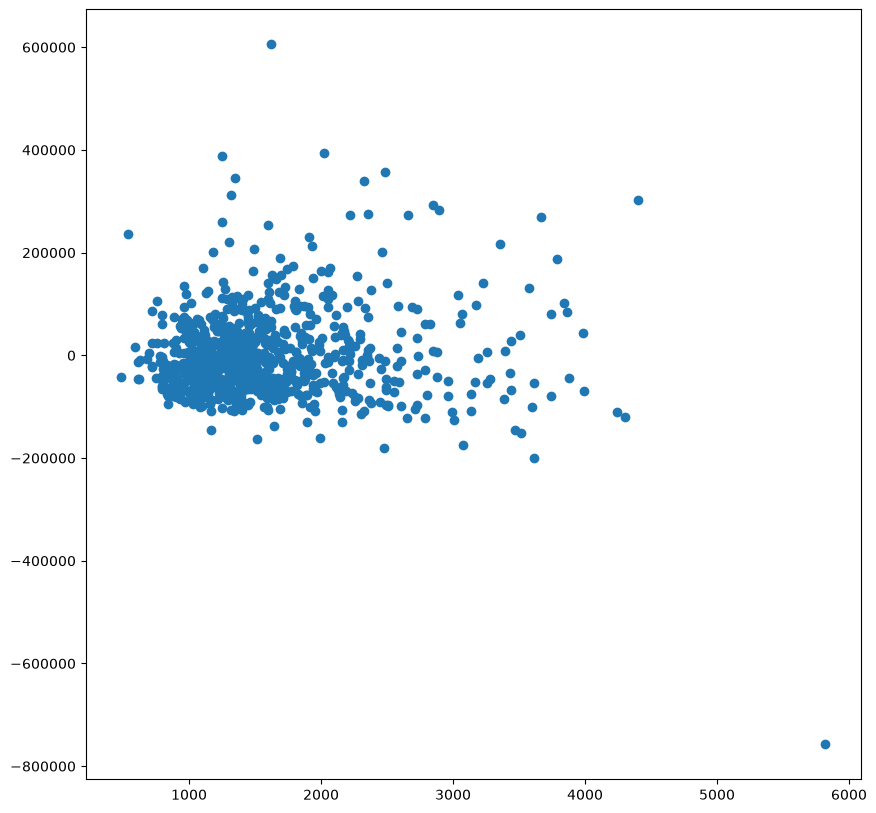

In [99]:
x=housing_cl['sq__ft']
y_pred = intercept + slope*x
residuals = housing_cl['price']-y_pred

plt.figure(figsize=(10, 10) )
plt.scatter(x ,residuals )
plt.show();

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [100]:
housing_cl = pd.get_dummies(housing_cl, columns=['type'], drop_first=True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [101]:
housing_cl.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,False,True
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,False,True
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,False,True
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,False,True
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,False,True


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [117]:
features = ['sq__ft' ,'type_Residential' ]
X=housing_cl[features]
y=housing_cl['price']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size= 0.25 ,random_state=1)

print(X_train.shape ,y_train.shape )
print(X_test.shape ,y_test.shape )

model=LinearRegression()

model.fit(X_train , y_train)
inter =model.intercept_
cof = model.coef_

score_train=model.score(X_train , y_train)
score_test=model.score(X_test , y_test)

print('score_train=' , score_train)
print('score_test=' , score_test)
print('')
print('intercept' , inter )
print('cofition' , cof )

(609, 2) (609,)
(204, 2) (204,)
score_train= 0.48597955585100283
score_test= 0.48591044388241256

intercept 3106.8114055905316
cofition [  123.57418697 31453.07923183]


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

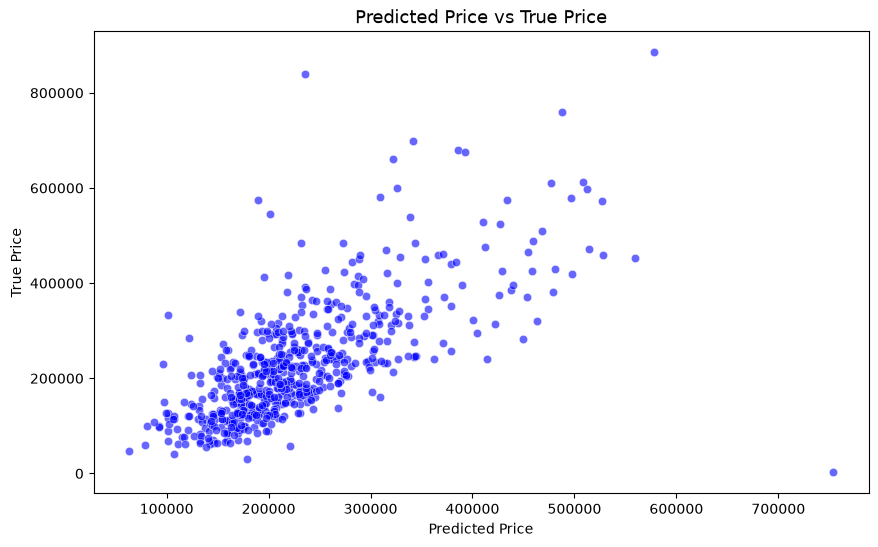

In [122]:
plt.figure(figsize=(10, 6))

y_preddicted = model.predict(X_train)

sns.scatterplot(x=y_preddicted, y=y_train, alpha=0.6, color='b')

plt.title('Predicted Price vs True Price', size=13)
plt.xlabel('Predicted Price')
plt.ylabel('True Price')
plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

In [ ]:
# **The Five Assumptions of the MLR Model (and Which Ones Are Shared with SLR):**

# 1. **Linearity** - The relationship between the independent variables and the dependent variable is linear. *(Shared with SLR)*
# 2. **Independence of errors** - The residuals are independent of each other (no serial correlation). *(Shared with SLR)*
# 3. **Homoscedasticity** - The variance of residuals is constant across all levels of the independent variables. *(Shared with SLR)*
# 4. **Normality of residuals** - The residuals roughly follow a normal distribution. *(Shared with SLR)*
# 5. **No/low Multicollinearity** - This assumption is **specific to MLR only** (it doesn’t make sense in SLR because there’s only one independent variable).

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

In [124]:
# **Evaluating Two Assumptions of Our Model:**

# - **Homoscedasticity:** From the residuals vs. `sqft` plot in question 8, it seems like the spread of residuals increases with larger square footage (fan-shaped). This suggests that the assumption is **not fully met** – errors are bigger for larger, more expensive houses.

# - **Low Multicollinearity:** The variables `sqft`, `beds`, and `baths` are moderately to strongly correlated (correlation around 0.66-0.72 between each pair) since they all reflect home size. This means that this assumption is **also not fully met**, which is one reason the model improved when `beds` was later removed in the iteration (Q18).

### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [126]:
def r2_adj(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

r2_test = r2_score(y_test, y_preddicted)
n_test = X_test.shape[0]
k_test = X_test.shape[1]


print(f"R2:            {r2_test:.4f}")
print(f"R2 Adjusted:   {r2_adj(r2_test, n_test, k_test):.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [204, 609]

### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?